# Level 15: Summarising Microbiome Count Data

In this notebook you will work with microbiome count data.

Each row is a microbial taxon. Each sample column contains a count.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the microbiome CSV

In [2]:
microbiome = pd.read_csv("data/microbiome_counts.csv")
microbiome

,taxon,control_1,control_2,control_3,disease_1,disease_2,disease_3
0,Bacteroides,350,410,390,220,250,230
1,Prevotella,120,100,130,300,340,310
2,Faecalibacterium,500,530,510,260,240,270
3,Escherichia,40,50,45,160,180,170
4,Lactobacillus,90,85,95,100,110,105
5,Bifidobacterium,200,190,210,130,125,140
6,Akkermansia,75,80,70,65,60,68
7,Streptococcus,55,60,58,150,145,155


## 2. Calculate total counts per taxon

In [3]:
sample_columns = ["control_1", "control_2", "control_3", "disease_1", "disease_2", "disease_3"]
microbiome["total_count"] = microbiome[sample_columns].sum(axis=1)
microbiome

,taxon,control_1,control_2,control_3,disease_1,disease_2,disease_3,total_count
0,Bacteroides,350,410,390,220,250,230,1850
1,Prevotella,120,100,130,300,340,310,1300
2,Faecalibacterium,500,530,510,260,240,270,2310
3,Escherichia,40,50,45,160,180,170,645
4,Lactobacillus,90,85,95,100,110,105,585
5,Bifidobacterium,200,190,210,130,125,140,995
6,Akkermansia,75,80,70,65,60,68,418
7,Streptococcus,55,60,58,150,145,155,623


## 3. Compare control and disease averages

In [4]:
control_columns = ["control_1", "control_2", "control_3"]
disease_columns = ["disease_1", "disease_2", "disease_3"]

microbiome["control_mean"] = microbiome[control_columns].mean(axis=1)
microbiome["disease_mean"] = microbiome[disease_columns].mean(axis=1)
microbiome[["taxon", "control_mean", "disease_mean"]]

,taxon,control_mean,disease_mean
0,Bacteroides,383.333333,233.333333
1,Prevotella,116.666667,316.666667
2,Faecalibacterium,513.333333,256.666667
3,Escherichia,45.000000,170.000000
4,Lactobacillus,90.000000,105.000000
5,Bifidobacterium,200.000000,131.666667
6,Akkermansia,75.000000,64.333333
7,Streptococcus,57.666667,150.000000


## 4. Calculate relative abundance

Relative abundance shows the proportion of all counts belonging to each taxon.

In [5]:
microbiome["relative_abundance"] = microbiome["total_count"] / microbiome["total_count"].sum()
microbiome[["taxon", "total_count", "relative_abundance"]]

,taxon,total_count,relative_abundance
0,Bacteroides,1850,0.212010
1,Prevotella,1300,0.148980
2,Faecalibacterium,2310,0.264726
3,Escherichia,645,0.073917
4,Lactobacillus,585,0.067041
5,Bifidobacterium,995,0.114027
6,Akkermansia,418,0.047903
7,Streptococcus,623,0.071396


## 5. Plot the most abundant taxa

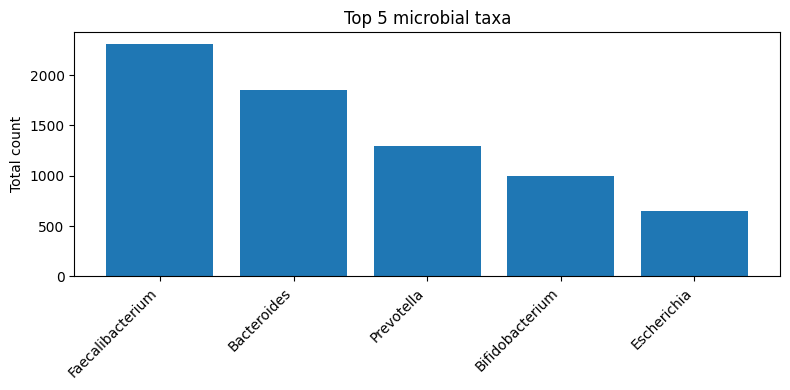

In [6]:
top_taxa = microbiome.sort_values("total_count", ascending=False).head(5)

plt.figure(figsize=(8, 4))
plt.bar(top_taxa["taxon"], top_taxa["total_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total count")
plt.title("Top 5 microbial taxa")
plt.tight_layout()
plt.show()

## Practice tasks

1. Find the taxon with the highest `disease_mean`.
2. Add a column called `difference` equal to `disease_mean - control_mean`.
3. Sort the table by `difference`, highest first.
4. Create a bar plot of `difference` for all taxa.
5. Save the final table to `data/microbiome_summary.csv`.

In [ ]:
# Write your answers here
